# Autonomous Teleoperation

This notebook uses the trained model to control the Jetbot autonomously. It leverages the model outputs to compute speed and steering, limiting rapid changes to prevent sudden jerks.
It has been optimized with `torch.no_grad()` and FP16 (`half()`) precision to run at high frequency (aiming near 60 fps).

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import cv2
import PIL.Image
import numpy as np
import time
import io
import atexit
import signal
import sys

import traitlets
import ipywidgets as widgets
from IPython.display import display
from PIL import ImageDraw

# ONNX Runtime (optional; used for .onnx model inference)
try:
    import onnxruntime as ort
    has_ort = True
except ImportError:
    ort = None
    has_ort = False
print(f'ONNX Runtime found: {has_ort}')
# JetBot hardware bindings (camera/motors)
try:
    from jetbot import Robot, Camera, bgr8_to_jpeg
    has_jetbot = True
except ImportError:
    has_jetbot = False
    print('jetbot not found - hardware cells will be skipped on this machine.')


ONNX Runtime found: True
jetbot not found - hardware cells will be skipped on this machine.


### Load the Model
We load our ResNet18 model and set it up for evaluation mode.
Note: For native PyTorch, it's very difficult to reach 60 FPS. Jetson Nano struggles with the framework overhead (usually yielding ~20-30 FPS for ResNet18).
For 60 FPS, the PyTorch model should ideally be compiled into a TensorRT optimized engine using `torch2trt`. 
If you have a TensorRT model (`best_steering_model_xy_trt.pth`), you should load that using `TRTModule()`. 
For now, we'll try to get the fastest native PyTorch performance using `half()` precision.

In [11]:
import os

# Guard TRT import
try:
    from torch2trt import TRTModule
    has_trtmodule = True
except Exception:
    TRTModule = None
    has_trtmodule = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model paths - edit to point to your trained weights
model_path      = 'best_steering_model_xy_mobilenetv3.pth'
trt_model_path  = '../models/best_steering_model_xy_trt.pth'
onnx_model_path = 'best_steering_model_xy_mobilenetv3.onnx'

# model_type: 'pytorch' | 'trt' | 'onnx'
model_type  = 'pytorch'
ort_session = None   # populated when model_type == 'onnx'


def _build_model_for_path(path):
    """Instantiate the correct architecture based on the filename."""
    name = os.path.basename(path).lower()
    if 'mobilenet' in name:
        m = torchvision.models.mobilenet_v3_small(weights=None)
        m.classifier[3] = torch.nn.Linear(m.classifier[3].in_features, 2)
        print('  Architecture: MobileNetV3 Large')
    else:
        m = torchvision.models.resnet18(weights=None)
        m.fc = torch.nn.Linear(512, 2)
        print('  Architecture: ResNet18')
    return m


if os.path.exists(onnx_model_path) and has_ort:
    print('Loading ONNX model via ONNX Runtime...')
    providers = (['CUDAExecutionProvider'] if torch.cuda.is_available() else []) + ['CPUExecutionProvider']
    ort_session = ort.InferenceSession(onnx_model_path, providers=providers)
    ort_input_name  = ort_session.get_inputs()[0].name
    ort_output_name = ort_session.get_outputs()[0].name
    model_type = 'onnx'
    model = None
    print(f'  Input : {ort_input_name}  {ort_session.get_inputs()[0].shape}')
    print(f'  Output: {ort_output_name}  {ort_session.get_outputs()[0].shape}')
elif os.path.exists(trt_model_path) and has_trtmodule and device.type == 'cuda':
    print('Loading optimized TensorRT model...')
    model = TRTModule()
    model.load_state_dict(torch.load(trt_model_path, map_location=device))
    model_type = 'trt'
elif os.path.exists(model_path):
    print('Loading standard PyTorch model...')
    model = _build_model_for_path(model_path)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device).eval()
    if device.type == 'cuda':
        model = model.half()
    model_type = 'pytorch'
else:
    raise FileNotFoundError(
        f'No model found. Expected one of:\n  {model_path}\n  {trt_model_path}\n  {onnx_model_path}'
    )

print(f'Active model_type: {model_type}')

Loading ONNX model via ONNX Runtime...
  Input : input  [1, 3, 224, 224]
  Output: output  [1, 2]
Active model_type: onnx


In [14]:
print(ort_session)

### Optimize Model with TensorRT (Optional)
Executing the code below will use `torch2trt` to create an optimized TensorRT engine. This process takes a few minutes but is required to reach high FPS (up to 60 FPS) on the Jetson Nano. 
Note: You only need to run this once or whenever you have a new trained model.

In [ ]:
# use to install torch2trt: 
!git clone https://github.com/NVIDIA-AI-IOT/torch2trt
!cd torch2trt
!python setup.py install

In [3]:
import os
# Convert to TensorRT only when torch2trt is available and a CUDA device exists
has_torch2trt = False
try:
    from torch2trt import torch2trt
    has_torch2trt = True
except Exception:
    pass

trt_model_path = '../models/best_steering_model_xy_trt.pth'
if has_torch2trt and torch.cuda.is_available():
    # 1. Create a dummy input (matching our 224x224 input size)
    data = torch.zeros((1, 3, 224, 224)).cuda().half()
    print("Starting TensorRT conversion... (this may take 2-5 minutes)")
    model_trt = torch2trt(model, [data], fp16_mode=True)
    torch.save(model_trt.state_dict(), trt_model_path)
    print(f"TensorRT model saved to {trt_model_path}")
    model = model_trt
else:
    print("torch2trt not available or CUDA not present; skipping conversion.")

torch2trt not available or CUDA not present; skipping conversion.


In [4]:
# Compatibility check: CUDA, PyTorch, and torch2trt
import torch
print('torch version:', getattr(torch, '__version__', None))
print('torch.cuda.is_available():', torch.cuda.is_available())
print('torch.version.cuda:', getattr(torch.version, 'cuda', None))

try:
    import torch2trt
    print('torch2trt import: OK')
except Exception as e:
    print('torch2trt import failed:', e)
    print('NOTE: torch2trt requires PyTorch built with CUDA and a system TensorRT installation.'
          )
    if not torch.cuda.is_available():
        print('CUDA not available: install a CUDA-enabled PyTorch build matching your CUDA driver.')
    print("Suggested (example) commands (adjust CUDA version & platform):")
    print('pip install --index-url https://download.pytorch.org/whl/cu118 torch torchvision torchaudio')
    print('git clone https://github.com/NVIDIA-AI-IOT/torch2trt && cd torch2trt && python setup.py install')

torch version: 2.12.0+cpu
torch.cuda.is_available(): False
torch.version.cuda: None
torch2trt import failed: No module named 'torch2trt'
NOTE: torch2trt requires PyTorch built with CUDA and a system TensorRT installation.
CUDA not available: install a CUDA-enabled PyTorch build matching your CUDA driver.
Suggested (example) commands (adjust CUDA version & platform):
pip install --index-url https://download.pytorch.org/whl/cu118 torch torchvision torchaudio
git clone https://github.com/NVIDIA-AI-IOT/torch2trt && cd torch2trt && python setup.py install


### High-Frequency Preprocessing
We pre-load mean/std constants directly to GPU to avoid CPU-GPU syncs on every frame.

In [9]:
# Prepare mean/std on the correct device and dtype
mean = torch.Tensor([0.485, 0.456, 0.406]).to(device)
std  = torch.Tensor([0.229, 0.224, 0.225]).to(device)


def preprocess(image):
    """Return model-ready input: tensor for PyTorch/TRT, float32 numpy for ONNX."""
    pil = PIL.Image.fromarray(image).resize((224, 224), PIL.Image.BILINEAR)
    t = transforms.functional.to_tensor(pil)
    if model_type == 'onnx':
        mean_reshaped = mean.cpu().view(3, 1, 1)
        std_reshaped = std.cpu().view(3, 1, 1)
        t = t.sub(mean_reshaped).div(std_reshaped)
        return t.unsqueeze(0).numpy().astype('float32')
    t = t.to(device)
    if device.type == 'cuda':
        t = t.half()
        m, s = mean.half(), std.half()
    else:
        m, s = mean, std
    t.sub_(m[:, None, None]).div_(s[:, None, None])
    return t[None, ...]


### Initialize Camera and Robot
Prepare the camera output and basic widgets so we can monitor what Jetbot sees.

In [ ]:
camera = Camera.instance()
robot = Robot()

image_widget = widgets.Image()
traitlets.dlink((camera, 'value'), (image_widget, 'value'), transform=bgr8_to_jpeg)

display(image_widget)

### UI Controls for Driving and Output Filters
Adjust `max_speed_delta` and `max_steering_delta` to limit how fast speed and direction can change.
This smoothing disallows sharp changes across individual frames.

In [6]:
# Speed gain controls the nominal forward speed of the robot.
speed_gain_slider = widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.2, description='speed gain')
# Steering gain scales the proportional steering response from the network angle.
steering_gain_slider = widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.2, description='steering gain')
# Steering KD adds a derivative term to damp quick angle changes.
steering_dgain_slider = widgets.FloatSlider(min=0.0, max=0.5, step=0.001, value=0.0, description='steering kd')
# Steering bias shifts the steering command left/right to compensate for hardware drift.
steering_bias_slider = widgets.FloatSlider(min=-0.5, max=0.5, step=0.01, value=0.0, description='steering bias')

# Delta clippers limit how quickly speed and steering can change from frame to frame.
max_speed_delta = widgets.FloatSlider(min=0.01, max=0.2, step=0.01, value=0.05, description='max speed delta')
max_steer_delta = widgets.FloatSlider(min=0.01, max=0.5, step=0.01, value=0.10, description='max steering delta')

# Target FPS caps how often the inference callback updates the motors.

controls_box = widgets.VBox([
    speed_gain_slider, 
    steering_gain_slider, 
    steering_dgain_slider, 
    steering_bias_slider,
    max_speed_delta,
    max_steer_delta,
])
display(controls_box)

# Diagnostic slider for the model's x output in normalized coordinates.
x_slider = widgets.FloatSlider(min=-1.0, max=1.0, description='network x')
# Diagnostic slider for the model's y output in normalized coordinates.
y_slider = widgets.FloatSlider(min=0, max=1.0, orientation='vertical', description='network y')
# Diagnostic slider showing the final steering command sent to the motors.
steering_slider = widgets.FloatSlider(min=-1.0, max=1.0, description='actual steer')
# Diagnostic slider showing the final speed command sent to the motors.
speed_slider = widgets.FloatSlider(min=0, max=1.0, orientation='vertical', description='actual speed')

display(widgets.HBox([y_slider, speed_slider]))
display(x_slider, steering_slider)

# Emergency stop button for inference control.
stop_inference_button = widgets.Button(description='⛔ Stop inference', button_style='danger')
display(stop_inference_button)

FloatSlider(value=0.0, description='network x', max=1.0, min=-1.0)

FloatSlider(value=0.0, description='actual steer', max=1.0, min=-1.0)

Button(button_style='danger', description='⛔ Stop inference', style=ButtonStyle())

### Inference Cycle
Listens to camera feed changes and directly evaluates to motor control.

In [7]:
angle = 0.0
angle_last = 0.0

current_speed = 0.0
current_steering = 0.0
last_inference_time = 0.0

DEBUG = False


def clamp_delta(new_val, old_val, max_delta):
    """Restricts how rapidly a value can change compared to the previous frame."""
    if new_val - old_val > max_delta:
        return old_val + max_delta
    elif old_val - new_val > max_delta:
        return old_val - max_delta
    return new_val


def run_inference(image):
    """Run the active model and return (x, y) normalized output coordinates."""
    if model_type == 'onnx':
        inp = preprocess(image)                              # (1,3,224,224) float32 numpy
        out = ort_session.run([ort_output_name], {ort_input_name: inp})[0]
        xy = out.flatten()
    else:
        with torch.no_grad():
            out = model(preprocess(image))
            xy = out.detach().float().cpu().numpy().flatten()
    return float(xy[0]), float(xy[1])


def execute(change):
    global angle, angle_last
    global current_speed, current_steering, last_inference_time

    current_time = time.time()
    if DEBUG:
        print(f"Inference  time: {last_inference_time - current_time}")
    last_inference_time = current_time

    image = change['new']
    x, y = run_inference(image)
    y = max(y, 1e-3)

    x_slider.value = x
    y_slider.value = y

    angle = np.arctan2(x, y)
    pid = angle * steering_gain_slider.value + (angle - angle_last) * steering_dgain_slider.value
    angle_last = angle

    target_steering = pid + steering_bias_slider.value
    target_speed    = speed_gain_slider.value

    current_speed    = clamp_delta(target_speed,    current_speed,    max_speed_delta.value)
    current_steering = clamp_delta(target_steering, current_steering, max_steer_delta.value)

    steering_slider.value = current_steering
    speed_slider.value    = current_speed

    left_power  = max(-1.0, min(1.0, current_speed + current_steering))
    right_power = max(-1.0, min(1.0, current_speed - current_steering))
    robot.left_motor.value  = left_power
    robot.right_motor.value = right_power


def start_inference(_=None):
    try:
        camera.unobserve(execute, names='value')
    except Exception:
        pass
    camera.observe(execute, names='value')
    print('Inference camera subscription is active.')


def stop_inference(_=None):
    global current_speed, current_steering
    try:
        camera.unobserve(execute, names='value')
    except Exception:
        pass
    robot.stop()
    current_speed    = 0.0
    current_steering = 0.0
    speed_slider.value    = 0.0
    steering_slider.value = 0.0
    print('Inference stopped and robot halted.')


stop_inference_button.on_click(stop_inference)


### Safe stopping of camera

In [ ]:
def cleanup(*args):

    global writer_running

    print("Stopping camera...")

    try:
        camera.unobserve(execute, names='value')
    except:
        pass


    try:
        camera.stop()
    except:
        pass

    try:
        camera.release()
    except:
        pass

    sys.exit(0)


# NORMAL EXIT
atexit.register(cleanup)

# CRASH / INTERRUPT HANDLERS
signal.signal(signal.SIGINT, cleanup)
signal.signal(signal.SIGTERM, cleanup)

### **Start driving!**
Executes whenever the camera captures a fresh frame.

In [ ]:
start_inference()

### Stop
Detach observation and pause robot.

In [ ]:
stop_inference()

Testing inference on: 1778600990.410001_mirror.png
Inference time: 0.0030 seconds


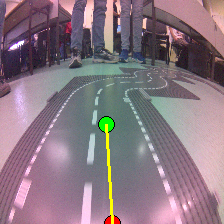


INFERENCE RESULTS
Network output (x, y): (-0.0574, 0.1070)
Predicted angle (rad): -0.4922
Target speed: 0.2000
Target steering: -0.0984

MOTOR POWERS:
  Left motor:  +0.1016
  Right motor: +0.2984

MOVEMENT DIRECTION:
  Speed magnitude: 0.2000 (0=stopped, 1=max)
  Turn angle: -28.20° (neg=left, pos=right)


In [81]:
# Test inference on random image from dataset
import os
import glob
import random
from PIL import Image, ImageDraw
from IPython.display import display

# Find a random image from dataset
image_dir = '../../data/dataset_images'
image_files = glob.glob(os.path.join(image_dir, '*.jpg')) + glob.glob(os.path.join(image_dir, '*.jpeg')) + glob.glob(os.path.join(image_dir, '*.png'))


def pixel_from_norm(x_norm, y_norm, img_size):
    px = int(round(x_norm * img_size / 2 + img_size / 2))
    py = int(round(y_norm * img_size / 2 + img_size / 2))
    px = max(0, min(px, img_size - 1))
    py = max(0, min(py, img_size - 1))
    return px, py

if image_files:
    random_image_path = random.choice(image_files)
    print(f"Testing inference on: {os.path.basename(random_image_path)}")
    
    # Load image
    test_image_pil = PIL.Image.open(random_image_path).convert('RGB')
    
    # Convert to numpy array for preprocessing
    test_image_np = np.array(test_image_pil)
    
    # Run inference
    current_time = time.time()
    time_taken = None
    if model_type == 'onnx':
        inp = preprocess(test_image_np)                              # (1,3,224,224) float32 numpy
        out = ort_session.run([ort_output_name], {ort_input_name: inp})[0]
        xy = out.flatten()
        time_taken = time.time() - current_time
    else:
        with torch.no_grad():
            out = model(preprocess(test_image_np))
            xy = out.detach().float().cpu().numpy().flatten()
            time_taken = time.time() - current_time
    print(f"Inference time: {time_taken:.4f} seconds")
    
    x_out = float(np.clip(xy[0], -1.0, 1.0))
    y_out = float(np.clip(xy[1], -1.0, 1.0))
    
    # Compute steering (same interpretation as training helper)
    angle_pred = np.arctan2(x_out, y_out)
    pid_steering = angle_pred * steering_gain_slider.value
    target_steering = pid_steering + steering_bias_slider.value
    target_speed = speed_gain_slider.value
    
    final_steering = np.clip(target_steering, -1.0, 1.0)
    final_speed = np.clip(target_speed, 0.0, 1.0)
    
    # Motor powers
    left_power_test = np.clip(final_speed + final_steering, -1.0, 1.0)
    right_power_test = np.clip(final_speed - final_steering, -1.0, 1.0)
    
    # Draw the same type of annotation used in the training notebook helper:
    # one point for the prediction, one for the image center/bottom reference, and a line between them.
    img_size = 224
    annotated = test_image_pil.resize((img_size, img_size), Image.Resampling.BILINEAR).copy()
    draw = ImageDraw.Draw(annotated)
    pred_px, pred_py = pixel_from_norm(x_out, y_out, img_size)
    center_x, center_y = img_size // 2, img_size - 1
    
    draw.ellipse((pred_px - 8, pred_py - 8, pred_px + 8, pred_py + 8), fill=(0, 255, 0), outline=(0, 0, 0))
    draw.ellipse((center_x - 8, center_y - 8, center_x + 8, center_y + 8), fill=(255, 0, 0), outline=(0, 0, 0))
    draw.line((pred_px, pred_py, center_x, center_y), fill=(255, 255, 0), width=3)
    
    display(annotated)
    
    # Display info
    print("\n" + "="*50)
    print("INFERENCE RESULTS")
    print("="*50)
    print(f"Network output (x, y): ({x_out:.4f}, {y_out:.4f})")
    print(f"Predicted angle (rad): {angle_pred:.4f}")
    print(f"Target speed: {final_speed:.4f}")
    print(f"Target steering: {final_steering:.4f}")
    print(f"\nMOTOR POWERS:")
    print(f"  Left motor:  {left_power_test:+.4f}")
    print(f"  Right motor: {right_power_test:+.4f}")
    print(f"\nMOVEMENT DIRECTION:")
    print(f"  Speed magnitude: {final_speed:.4f} (0=stopped, 1=max)")
    print(f"  Turn angle: {np.degrees(angle_pred):.2f}° (neg=left, pos=right)")
    print("="*50)
else:
    print(f"No images found in {image_dir}")

### Live Camera Visualization with Predictions

Displays the robot's camera feed with the model's predicted steering point overlaid.
- **Green dot** - predicted target point (where the network wants to steer)
- **Red dot** - robot position reference (image bottom-center)
- **Yellow line** - steering direction

On JetBot: starts a live annotated feed. Offline: annotates random dataset images.
Run the **Stop Visualization** button when done to free the camera observer.


In [ ]:
def _pixel_from_norm(x_norm, y_norm, w, h):
    px = int(round(x_norm * w / 2 + w / 2))
    py = int(round(y_norm * h / 2 + h / 2))
    return max(0, min(px, w - 1)), max(0, min(py, h - 1))


def _annotate_frame(bgr_frame, x_out, y_out, steer, spd):
    rgb = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
    pil_img = PIL.Image.fromarray(rgb)
    w, h = pil_img.size
    draw = ImageDraw.Draw(pil_img)

    px, py = _pixel_from_norm(x_out, y_out, w, h)
    cx, cy = w // 2, h - 1

    draw.line((px, py, cx, cy), fill=(255, 255, 0), width=2)
    draw.ellipse((px - 8, py - 8, px + 8, py + 8), fill=(0, 255, 0), outline=(0, 0, 0))
    draw.ellipse((cx - 8, cy - 8, cx + 8, cy + 8), fill=(255, 0,   0), outline=(0, 0, 0))
    draw.text((4, 4),  f'steer: {steer:+.3f}', fill=(255, 255, 255))
    draw.text((4, 18), f'speed: {spd:.3f}',     fill=(255, 255, 255))
    draw.text((4, 32), f'model: {model_type}',   fill=(200, 200, 200))

    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG')
    return buf.getvalue()


if has_jetbot:
    # Live annotated camera feed on JetBot
    vis_widget   = widgets.Image(format='jpeg', width=320, height=240)
    stop_vis_btn = widgets.Button(description='Stop Visualization', button_style='warning')
    display(widgets.VBox([vis_widget, stop_vis_btn]))

    def _vis_execute(change):
        img = change['new']
        x, y = run_inference(img)
        ang   = np.arctan2(x, max(y, 1e-3))
        steer = ang * steering_gain_slider.value + steering_bias_slider.value
        spd   = speed_gain_slider.value
        vis_widget.value = _annotate_frame(img, x, y, steer, spd)

    def _stop_visualization(_=None):
        try:
            camera.unobserve(_vis_execute, names='value')
        except Exception:
            pass
        print('Visualization stopped.')

    stop_vis_btn.on_click(_stop_visualization)
    try:
        camera.unobserve(_vis_execute, names='value')
    except Exception:
        pass
    camera.observe(_vis_execute, names='value')
    print('Live visualization started.')

else:
    # Offline: annotate random dataset images for inspection
    import glob, random
    image_dir  = '../../data/dataset_images'
    img_files  = (glob.glob(f'{image_dir}/*.jpg') +
                  glob.glob(f'{image_dir}/*.jpeg') +
                  glob.glob(f'{image_dir}/*.png'))

    if not img_files:
        print(f'No images found in {image_dir}')
    else:
        for img_path in random.sample(img_files, min(4, len(img_files))):
            img_pil = PIL.Image.open(img_path).convert('RGB')
            img_np  = np.array(img_pil)
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

            x, y  = run_inference(img_np)
            ang   = np.arctan2(x, max(y, 1e-3))
            steer = ang * steering_gain_slider.value + steering_bias_slider.value
            spd   = speed_gain_slider.value

            print(f'{os.path.basename(img_path):40s}  '
                  f'x={x:+.3f}  y={y:+.3f}  steer={steer:+.3f}  speed={spd:.3f}')
            display(widgets.Image(value=_annotate_frame(img_bgr, x, y, steer, spd), format='jpeg'))
